# LSTM Model Training for Hand Sign Detection

This notebook trains an LSTM neural network for dynamic hand sign/gesture recognition using the WLASL dataset.

## Overview
1. **Data Loading** - Process videos from `data/videos/` using `WlaslPreprocessor`
2. **Preprocessing** - Normalize, reshape for LSTM
3. **Model Building** - Create LSTM architecture with Keras
4. **Training** - Train with callbacks
5. **Evaluation** - Visualize results
6. **Save Model** - Export to `models/`

In [22]:
%pip install scikit-learn matplotlib seaborn tensorflow

# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import json
import sys
import os
import warnings
import logging

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.utils import to_categorical

# Add project src to path for imports
PROJECT_ROOT = Path("../").resolve()
SRC_PATH = PROJECT_ROOT / "src"
if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

warnings.filterwarnings('ignore')
np.random.seed(42)
tf.random.set_seed(42)

# Configure logging
logging.basicConfig(level=logging.INFO, format='%(asctime)s - %(levelname)s - %(message)s')
logger = logging.getLogger("lstm_training")

print(f"TensorFlow version: {tf.__version__}")
print(f"GPU available: {tf.config.list_physical_devices('GPU')}")
print(f"Project root: {PROJECT_ROOT}")

Note: you may need to restart the kernel to use updated packages.
TensorFlow version: 2.21.0
GPU available: []
Project root: C:\Users\suman\Documents\hand_sign_detection_dynamic


In [23]:
%pip install pydantic pydantic-settings

# Import the preprocessor for data loading
from hand_sign_detection.training.preprocessor import WlaslPreprocessor

print("✅ Imports successful. Ready to train LSTM model.")

Note: you may need to restart the kernel to use updated packages.
✅ Imports successful. Ready to train LSTM model.


In [24]:
import os
import sys

# 1. Check current working directory
print(f"Current Directory: {os.getcwd()}")

# 2. Look for the 'src' folder
if os.path.exists(r"C:\Users\suman\Documents\hand_sign_detection_dynamic\src\hand_sign_detection\training\preprocessor.py"):
    print("✅ Found 'src' folder!")
    src_path = os.path.abspath(r"C:\Users\suman\Documents\hand_sign_detection_dynamic\src\hand_sign_detection\training\preprocessor.py")
    if src_path not in sys.path:
        sys.path.append(src_path)
        print(f"Added {src_path} to sys.path")
else:
    print("❌ 'src' folder NOT FOUND. You might be in the wrong directory.")
    print("Folders here:", os.listdir('.'))

# 3. Final attempt at import
try:
    from hand_sign_detection.training.preprocessor import WlaslPreprocessor
    print("🚀 SUCCESS! Import worked.")
except ModuleNotFoundError as e:
    print(f"FAILED: {e}")

Current Directory: c:\Users\suman\Documents\hand_sign_detection_dynamic\notebooks
✅ Found 'src' folder!
🚀 SUCCESS! Import worked.


In [25]:
# Configuration
DATA_DIR = PROJECT_ROOT / "data"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)

# Video processing config - set to None to use ALL 11,998 videos
PREPROCESS_CONFIG = {
    "json_file": str(DATA_DIR / "WLASL_v0.3.json"),
    "video_folder": str(DATA_DIR / "videos"),
    "max_classes": None,  # None = use all classes
    "max_videos_per_class": None,  # None = use all videos per class
    "sequence_length": 30,
    "frame_stride": 2,
    "save_data": True,
    "parallel": True,  # Enable parallel processing
    "n_workers": None,  # None = CPU count - 1
}

# Model config
CONFIG = {
    "sequence_length": 30,
    "n_features": 126,
    "validation_split": 0.2,
    "test_split": 0.1,
    "lstm_units_1": 128,
    "lstm_units_2": 64,
    "dropout_rate": 0.3,
    "dense_units": 64,
    "batch_size": 32,
    "epochs": 100,
    "learning_rate": 0.001,
    "early_stopping_patience": 15,
    "reduce_lr_patience": 5
}

print(f"JSON file: {PREPROCESS_CONFIG['json_file']}")
print(f"Video folder: {PREPROCESS_CONFIG['video_folder']}")
print(f"Max classes: {PREPROCESS_CONFIG['max_classes'] or 'ALL'}")
print(f"Parallel processing: {PREPROCESS_CONFIG['parallel']}")

JSON file: C:\Users\suman\Documents\hand_sign_detection_dynamic\data\WLASL_v0.3.json
Video folder: C:\Users\suman\Documents\hand_sign_detection_dynamic\data\videos
Max classes: ALL
Parallel processing: True


---
## Data Loading

Uses `WlaslPreprocessor` to process videos from `data/videos/`. First run takes 30-60+ minutes. Data is cached to `.npy` files for subsequent runs.

In [26]:
def load_or_process_videos():
    """Load cached data or process all 11,998 videos with parallel processing."""
    x_path = DATA_DIR / "X_data.npy"
    y_path = DATA_DIR / "y_data.npy"
    labels_path = MODELS_DIR / "wlasl_labels.npy"
    
    # Check for cached data
    if x_path.exists() and y_path.exists():
        print("Loading cached preprocessed data...")
        X_data = np.load(x_path)
        y_data = np.load(y_path)
        labels = np.load(labels_path, allow_pickle=True).tolist() if labels_path.exists() else [f"class_{i}" for i in range(len(np.unique(y_data)))]
        print(f"Loaded: X={X_data.shape}, y={y_data.shape}, classes={len(labels)}")
        return X_data, y_data, labels
    
    # Process ALL videos with parallel processing
    print("No cached data. Processing ALL videos (this may take 1-2 hours)...")
    print(f"Parallel processing enabled: {PREPROCESS_CONFIG['parallel']}")
    preprocessor = WlaslPreprocessor()
    
    X_data, y_data = preprocessor.process_videos(
        json_file=PREPROCESS_CONFIG["json_file"],
        video_folder=PREPROCESS_CONFIG["video_folder"],
        max_classes=PREPROCESS_CONFIG["max_classes"],
        max_videos_per_class=PREPROCESS_CONFIG["max_videos_per_class"],
        sequence_length=PREPROCESS_CONFIG["sequence_length"],
        frame_stride=PREPROCESS_CONFIG["frame_stride"],
        save_data=PREPROCESS_CONFIG["save_data"],
        parallel=PREPROCESS_CONFIG["parallel"],
        n_workers=PREPROCESS_CONFIG["n_workers"],
    )
    
    labels = np.load(labels_path, allow_pickle=True).tolist() if labels_path.exists() else [f"class_{i}" for i in range(len(np.unique(y_data)))]
    print(f"Processed: X={X_data.shape}, y={y_data.shape}")
    print(f"Summary: {preprocessor.last_summary}")
    return X_data, y_data, labels

# Load data
print("="*60)
X_raw, y_raw, class_labels = load_or_process_videos()
print("="*60)
print(f"\nData: X={X_raw.shape}, y={y_raw.shape}, classes={len(class_labels)}")
print(f"First 10 classes: {class_labels[:10]}")

Loading cached preprocessed data...
Loaded: X=(11, 30, 8), y=(11,), classes=10

Data: X=(11, 30, 8), y=(11,), classes=10
First 10 classes: ['book', 'drink', 'computer', 'before', 'chair', 'go', 'clothes', 'who', 'candy', 'cousin']


In [27]:
# Update config with actual dimensions
if len(X_raw.shape) == 3:
    CONFIG["sequence_length"] = X_raw.shape[1]
    CONFIG["n_features"] = X_raw.shape[2]
n_classes = len(np.unique(y_raw))
CONFIG["n_classes"] = n_classes

print(f"Sequence length: {CONFIG['sequence_length']}")
print(f"Features/frame: {CONFIG['n_features']}")
print(f"Classes: {n_classes}")

Sequence length: 30
Features/frame: 8
Classes: 6


Samples: 11, Classes: 6
Min/class: 1, Max: 3, Mean: 1.8


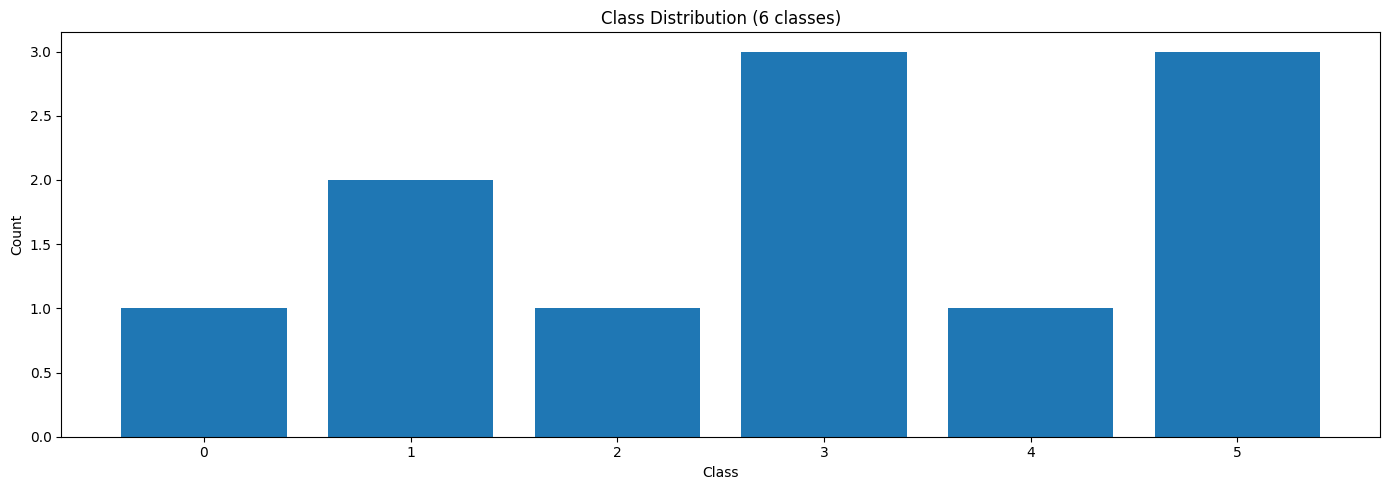

In [28]:
# Class distribution
unique_labels, label_counts = np.unique(y_raw, return_counts=True)
print(f"Samples: {len(y_raw)}, Classes: {len(unique_labels)}")
print(f"Min/class: {label_counts.min()}, Max: {label_counts.max()}, Mean: {label_counts.mean():.1f}")

plt.figure(figsize=(14, 5))
plt.bar(range(len(unique_labels)), label_counts)
plt.xlabel("Class")
plt.ylabel("Count")
plt.title(f"Class Distribution ({n_classes} classes)")
plt.tight_layout()
plt.show()

## Preprocessing

In [29]:
# Clean and normalize
X_clean = np.nan_to_num(X_raw, nan=0.0, posinf=0.0, neginf=0.0)

n_samples, timesteps, n_features = X_clean.shape
X_flat = X_clean.reshape(-1, n_features)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_flat).reshape(n_samples, timesteps, n_features)

# Encode labels
label_encoder = LabelEncoder()
y_encoded = label_encoder.fit_transform(y_raw)
y_onehot = to_categorical(y_encoded, num_classes=n_classes)

print(f"Normalized: mean={X_scaled.mean():.4f}, std={X_scaled.std():.4f}")
print(f"Labels: {n_classes} classes")

Normalized: mean=0.0000, std=1.0000
Labels: 6 classes


In [30]:
# Filter out classes with only 1 sample (required for stratified split)
unique_classes, class_counts = np.unique(y_encoded, return_counts=True)
valid_classes = unique_classes[class_counts >= 2]
valid_indices = np.isin(y_encoded, valid_classes)

X_filtered = X_scaled[valid_indices]
y_filtered = y_encoded[valid_indices]
y_onehot_filtered = y_onehot[valid_indices]

print(f"Filtered: Removed {(~valid_indices).sum()} samples from classes with <2 members")
print(f"Remaining samples: {X_filtered.shape[0]}, Classes: {len(valid_classes)}")

# Split data with stratification (auto-adjust test_size for small datasets)
n_filtered = len(y_filtered)
n_valid_classes = len(np.unique(y_filtered))
min_test_size = n_valid_classes / n_filtered  # need at least 1 sample per class in test
test_size = max(CONFIG["test_split"], min_test_size)

X_trainval, X_test, y_trainval, y_test, y_trainval_labels, y_test_labels = train_test_split(
    X_filtered,
    y_onehot_filtered,
    y_filtered,
    test_size=test_size,
    random_state=42,
    stratify=y_filtered
)

val_ratio = CONFIG["validation_split"] / (1 - test_size)
X_train, X_val, y_train, y_val = train_test_split(
    X_trainval, y_trainval, test_size=val_ratio, random_state=42
)

print(f"Adjusted test_size: {test_size:.3f}")
print(f"Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}")

Filtered: Removed 3 samples from classes with <2 members
Remaining samples: 8, Classes: 3
Adjusted test_size: 0.375
Train: 3, Val: 2, Test: 3


## Model Building

In [31]:
def build_lstm_model(input_shape, n_classes, config):
    model = Sequential([
        LSTM(config["lstm_units_1"], input_shape=input_shape, return_sequences=True),
        BatchNormalization(),
        Dropout(config["dropout_rate"]),
        LSTM(config["lstm_units_2"], return_sequences=False),
        BatchNormalization(),
        Dropout(config["dropout_rate"]),
        Dense(config["dense_units"], activation="relu"),
        Dropout(config["dropout_rate"] / 2),
        Dense(n_classes, activation="softmax")
    ])
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=config["learning_rate"]),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model = build_lstm_model((CONFIG["sequence_length"], CONFIG["n_features"]), n_classes, CONFIG)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 30, 128)        │        70,144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 30, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 124,870 (487.77 KB)

 Trainable params: 124,486 (486.27 KB)

 Non-trainable params: 384 (1.50 KB)

## Training

In [32]:
callbacks = [
    EarlyStopping(monitor="val_loss", patience=CONFIG["early_stopping_patience"], restore_best_weights=True),
    ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=CONFIG["reduce_lr_patience"], min_lr=1e-6),
    ModelCheckpoint(str(MODELS_DIR / "lstm_best.keras"), monitor="val_accuracy", save_best_only=True)
]

print(f"Training for up to {CONFIG['epochs']} epochs...")
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=CONFIG["epochs"],
    batch_size=CONFIG["batch_size"],
    callbacks=callbacks,
    verbose=1
)

Training for up to 100 epochs...
Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step - accuracy: 0.0000e+00 - loss: 2.5224 - val_accuracy: 0.5000 - val_loss: 1.5991 - learning_rate: 0.0010
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step - accuracy: 0.6667 - loss: 1.3973 - val_accuracy: 0.5000 - val_loss: 1.5834 - learning_rate: 0.0010
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step - accuracy: 1.0000 - loss: 0.4841 - val_accuracy: 0.5000 - val_loss: 1.5719 - learning_rate: 0.0010
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.5399 - val_accuracy: 0.5000 - val_loss: 1.5591 - learning_rate: 0.0010
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 1.0000 - loss: 0.4680 - val_accuracy: 0.5000 - val_loss: 1.5555 - learning_rate: 0.0010
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 1.0000 - loss: 0.1152 - val_accuracy: 0.5000 - val_loss: 1.5517 - learning_rate: 0.0010
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step - accuracy: 1.0

## Evaluation

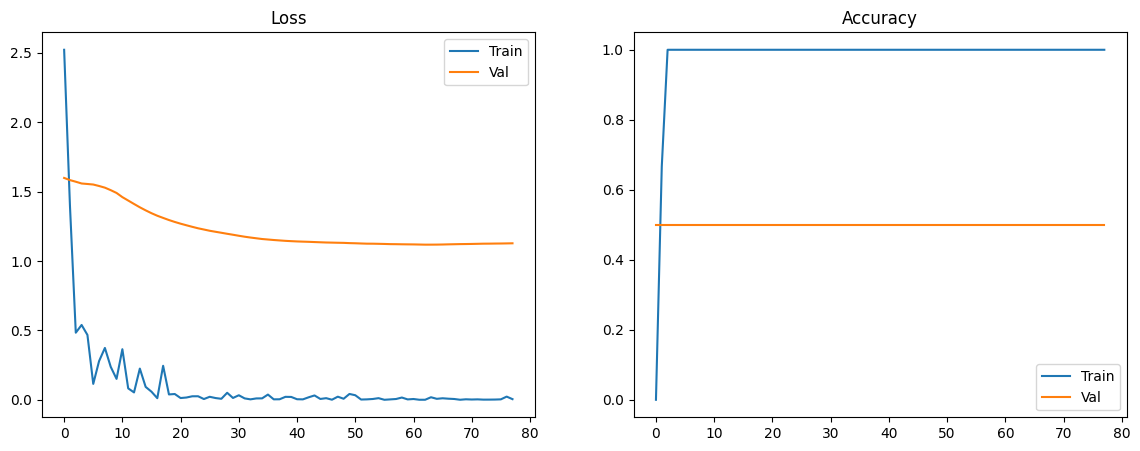

In [33]:
# Training history
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(history.history['loss'], label='Train')
axes[0].plot(history.history['val_loss'], label='Val')
axes[0].set_title('Loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='Train')
axes[1].plot(history.history['val_accuracy'], label='Val')
axes[1].set_title('Accuracy')
axes[1].legend()

plt.savefig(MODELS_DIR / "training_history.png", dpi=150)
plt.show()

In [34]:
# Test evaluation
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

Test Loss: 2.1492
Test Accuracy: 0.0000 (0.00%)


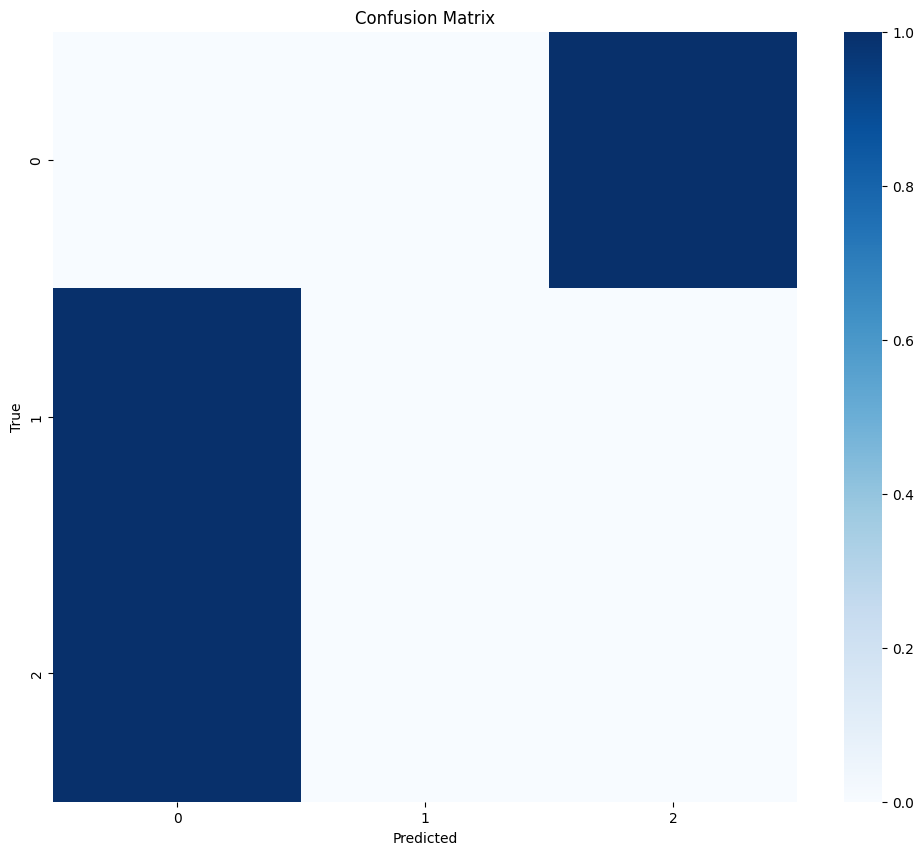


Classification Report:
              precision    recall  f1-score   support

           1       0.00      0.00      0.00       1.0
           3       0.00      0.00      0.00       1.0
           5       0.00      0.00      0.00       1.0

    accuracy                           0.00       3.0
   macro avg       0.00      0.00      0.00       3.0
weighted avg       0.00      0.00      0.00       3.0



In [35]:
# Confusion matrix
y_pred = np.argmax(model.predict(X_test, verbose=0), axis=1)
y_true = np.argmax(y_test, axis=1)

plt.figure(figsize=(12, 10))
cm = confusion_matrix(y_true, y_pred)
sns.heatmap(cm, cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Confusion Matrix')
plt.savefig(MODELS_DIR / "confusion_matrix.png", dpi=150)
plt.show()

print("\nClassification Report:")
print(classification_report(y_true, y_pred))

## Save Model

In [ ]:
import joblib

model.save(MODELS_DIR / "gesture_model.keras")
model.save(MODELS_DIR / "gesture_model.h5")
np.save(MODELS_DIR / "class_labels.npy", np.array(class_labels))
joblib.dump(scaler, MODELS_DIR / "feature_scaler.pkl")
joblib.dump(label_encoder, MODELS_DIR / "label_encoder.pkl")

with open(MODELS_DIR / "model_config.json", "w") as f:
    json.dump(CONFIG, f, indent=2)

print("Saved to models/:")
for f in sorted(MODELS_DIR.iterdir()):
    if f.is_file():
        print(f"  {f.name}: {f.stat().st_size/1024:.1f} KB")

2026-04-06 05:42:04,840 - WARNING - You are saving your model as an HDF5 file via `model.save()` or `keras.saving.save_model(model)`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')` or `keras.saving.save_model(model, 'my_model.keras')`. 


Saved to models/:
  class_labels.npy: 0.4 KB
  confusion_matrix.png: 29.2 KB
  feature_scaler.pkl: 0.8 KB
  gesture_model.h5: 1521.2 KB
  gesture_model.keras: 1515.0 KB
  hand_alphabet_model.pkl: 18636.0 KB
  label_encoder.pkl: 0.4 KB
  lstm_best.keras: 1515.0 KB
  model_config.json: 0.3 KB
  README.md: 2.5 KB
  shared_backend_state.json: 0.6 KB
  training_history.png: 53.4 KB
  wlasl_labels.npy: 0.4 KB
